<a href="https://colab.research.google.com/github/ThibaultDesjonqueres/-KSAT-radis-main/blob/develop/unbreakable_collab_version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Clone the repo
!git clone https://github.com/mikhailsirenko/unbreakable.git

# Change into repo directory
import os
os.chdir('/content/unbreakable')
print("Working directory:", os.getcwd())

# Install dependencies
!pip install -r requirements.txt

# After the next line, you MUST manually restart the runtime, and run this
!pip install -e .

fatal: destination path 'unbreakable' already exists and is not an empty directory.
Working directory: /content/unbreakable
Obtaining file:///content/unbreakable
  Preparing metadata (setup.py) ... done
  Attempting uninstall: unbreakable
    Found existing installation: unbreakable 0.4.0
    Uninstalling unbreakable-0.4.0:
      Successfully uninstalled unbreakable-0.4.0
  Running setup.py develop for unbreakable


In [6]:
os.chdir('/content/unbreakable/unbreakable')

# I modified the function example.py with n_scenarios = 2, n_processes = 2
!python example.py


/usr/local/lib/python3.11/dist-packages/ema_workbench/em_framework/futures_multiprocessing.py:262: UserWarning: The number of processes cannot be more then 2
  warnings.warn(
[MainProcess/INFO] pool started with 2 workers
[MainProcess/INFO] performing 3 scenarios * 1 policies * 1 model(s) = 3 experiments
100%|████████████████████████████████████████████| 3/3 [00:42<00:00, 14.32s/it]
[MainProcess/INFO] experiments finished
[MainProcess/INFO] terminating pool
[MainProcess/INFO] results saved successfully to /content/unbreakable/results/Example/disaster_type=flood_return_period=250_scenarios=3_policies=0.tar.gz


In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import geopandas as gpd
from ema_workbench import load_results
import os
from experiments.experiment_results_formatter import format_experiment_results
from ema_workbench import load_results
import importlib
import experiments.experiment_results_formatter as erf

In [15]:
country = "Example"
disaster_type = "flood"
return_period = 250
n_scenarios = 3 # 100
n_policies = 0

spu_name = 'Region'

# Get the current working directory
os.chdir('/content/unbreakable')
current_dir = os.getcwd()
print('current_dir', current_dir)
# Build the results path by joining absolute paths dynamically
results_path = os.path.join(
    current_dir, "results", country,
    f"disaster_type={disaster_type}_return_period={return_period}_scenarios={n_scenarios}_policies={n_policies}.tar.gz"
)

print(os.path.exists(results_path))
#  Now try to load the results
results = load_results(results_path)
results = format_experiment_results(results, include_policies=False, include_uncertainties=False)

current_dir /content/unbreakable
True


## Economic impacts

In [16]:
economic_columns = [
    "avg_annual_consumption_loss",
    "avg_annual_consumption_loss_pct",
]
results['annual_average_consumption_loss_pct'] *= 100

In [17]:
results['annual_average_consumption_loss_pct'].describe()

,annual_average_consumption_loss_pct
count,9.000000
mean,18.205731
std,0.545437
min,17.585260
25%,17.709176
50%,18.253001
75%,18.780162
max,18.878928


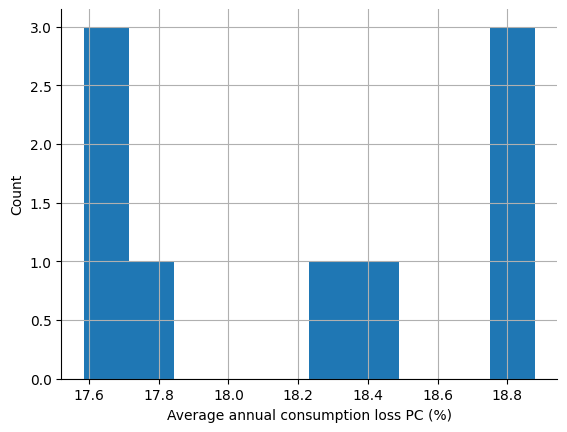

In [18]:
results['annual_average_consumption_loss_pct'].hist();
plt.ylabel("Count");
plt.xlabel("Average annual consumption loss PC (%)");
sns.despine()

In [19]:
results.groupby('spatial_unit')['annual_average_consumption_loss_pct'].describe()[['mean', 'std']].sort_values('mean', ascending=False).round(2)

,mean,std
spatial_unit,,
region_2,18.84,0.05
region_1,18.07,0.42
region_0,17.71,0.02


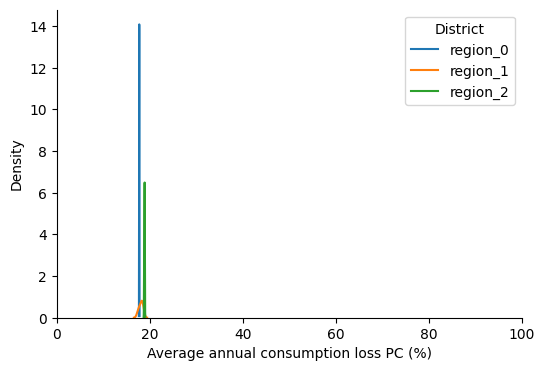

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
for spatial_unit in results['spatial_unit'].unique():
    spatial_unit_results = results[results['spatial_unit'] == spatial_unit]
    sns.kdeplot(
            data=spatial_unit_results,
            x="annual_average_consumption_loss_pct",
            ax=ax,
            alpha=1,
            label=spatial_unit,
        )
    sns.despine()
plt.xlim(0, 100)
plt.xlabel("Average annual consumption loss PC (%)")
plt.ylabel("Density")
plt.legend(title="District");

## Poverty impacts

In [21]:
# TODO: It seems that there is no variance between the model runs.
new_poor_count = results.groupby('spatial_unit')['new_poor_count'].describe().round(2)
new_poor_count.index.name = 'District'
new_poor_count = new_poor_count.drop(columns=['count',
                                              #'std',
                                               'min',
                                            #    '25%',
                                               '50%',
                                            #    '75%',
                                               'max'
                                              ])
new_poor_count.columns = ['Mean',
                          'Std',
                          'Min',
                          # '25%',
                          # '50%',
                          # '75%',
                          'Max'
                          ]
new_poor_count.sort_values('Mean', ascending=False).style.format("{:,.0f}")

,Mean,Std,Min,Max
District,,,,
region_0,0,0,0,0
region_1,0,0,0,0
region_2,0,0,0,0


In [22]:
poverty_duration_columns = [f'poverty_duration_{i}'for i in range(1, 11)]
poverty_duration = results[['spatial_unit'] + poverty_duration_columns].groupby('spatial_unit').mean().round(2).sort_values(by='poverty_duration_5', ascending=False).round()
poverty_duration.columns = np.arange(1, 11)
poverty_duration.index.name = spu_name
poverty_duration = poverty_duration.replace(0, np.nan)
poverty_duration.sort_values(1, ascending=False).iloc[:,:3].to_csv('/content/poverty_duration.csv')

In [23]:
poverty_duration.sort_values(1, ascending=False).iloc[:,:3]

,1,2,3
Region,,,
region_0,NaN,NaN,NaN
region_1,NaN,NaN,NaN
region_2,NaN,NaN,NaN
